In [ ]:
# repo-root bootstrap: notebooks live in notebooks/, code lives one level up
import sys, pathlib
_root = pathlib.Path.cwd()
if not (_root / "spphot_eval.py").exists():
    _root = _root.parent
sys.path.insert(0, str(_root))


In [20]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

sweeps = {}

original_data = pl.scan_parquet('/scratch/mk27/mj8805/bulge-ages-and-orbits/data/spectra_infer_parallax_zpt.parquet')

data = {}
for beta in [0.2, 0.3, 0.5, 0.7]:
    fname = f'/scratch/mk27/mj8805/spphot_nn_results_gauss-beta{beta}.parquet'
    data[beta] = pd.read_parquet(fname)

In [21]:
import numpy as np

In [22]:
len(data[0.2])

825248

In [23]:
data[0.2].head()

,sdss_id,plx,e_plx,plx_raw,zeropoint,plx_sp,err_sp,dist_sp_kpc,r_med_photogeo_pc,sample,train,spec_bad_frac
0,100000028,0.164583,0.023733,0.120654,-0.043929,0.186907,0.002720,5.350257,5847.649902,B,False,0.101691
1,100000156,0.058013,0.035814,0.015124,-0.042889,0.128492,0.001121,7.782608,10633.925781,B,False,0.107172
2,100000167,0.164350,0.016947,0.122790,-0.041560,0.164928,0.015855,6.063255,5986.399902,B,True,0.097259
3,100000172,0.142142,0.020179,0.101950,-0.040192,0.201228,0.002289,4.969484,7088.578125,A,False,0.100991
4,100000181,0.134440,0.017905,0.083680,-0.050760,0.110157,0.002718,9.077931,7917.260254,B,False,0.097376


In [24]:
import sys
sys.path.append('/scratch/mk27/mj8805/distance-estimator/')
import glob, pandas as pd, numpy as np, spphot_eval as E

df = data[0.2]
for fold in ("A", "B"):                      # honest: held-out predictions only
    d = df[df["sample"].astype(str).str.strip() == fold]
    a  = dict(plx_sp=d.plx_sp.values, plx_a=d.plx.values,
                err_a=d.e_plx.values, err_sp=d.err_sp.values)
    print(f"  -- fold {fold} --")
    # 1) bias vs PREDICTED ERROR  (does the -2% live in the high-err tail?)
    E.print_bias_bins(E.bias_bins(**a))
    # 2) bias vs BJ DISTANCE      (proxy for faint/distant)
    E.print_bias_bins(E.bias_bins(**a, by=d.r_med_photogeo_pc.values,
                                    by_label="r_bj_pc"))

  -- fold A --
  bias localization (high-S/N probe, binned by pred_err_frac):
    pred_err_   bias%   scat%      N
        0.024   -1.73  10.15    9501
        0.040   -0.77   8.82    9501
        0.050   -0.58   8.00    9500
        0.058   -0.53   7.87    9501
        0.065   -0.78   7.70    9501
        0.071   -0.97   7.94    9500
        0.080   -1.42   8.66    9501
        0.100   -3.09  11.06    9501
    (flat bias column = global offset fixes it; trend = bias lives in one regime -> de-bias there or raise beta)
  bias localization (high-S/N probe, binned by r_bj_pc):
      r_bj_pc   bias%   scat%      N
      971.898   -2.37   6.71    9500
     1449.951   -1.36   7.07    9499
     1807.323   -1.83   8.08    9500
     2114.663   -1.58   8.60    9499
     2415.726   -1.45   9.09    9500
     2729.093   -0.99   9.55    9499
     3096.421   -0.19   9.93    9500
     3678.827   +1.98  11.03    9500
    (flat bias column = global offset fixes it; trend = bias lives in one regime -> de

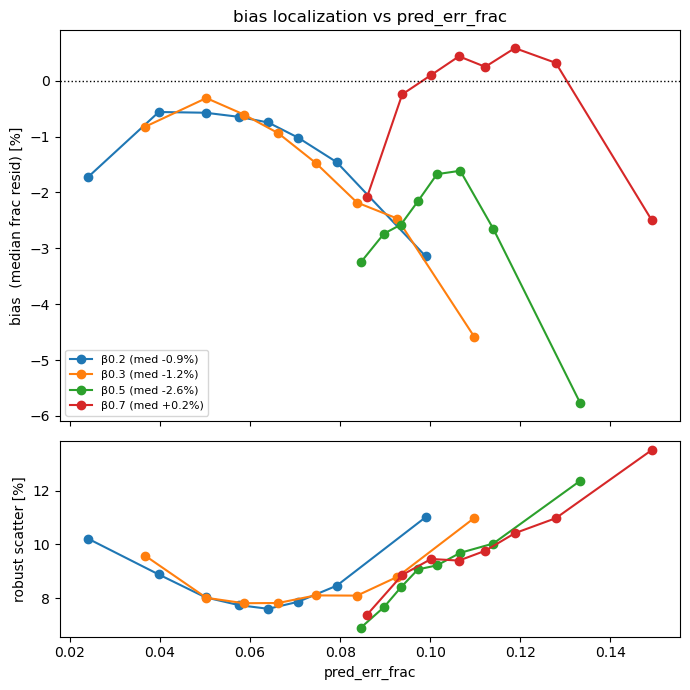

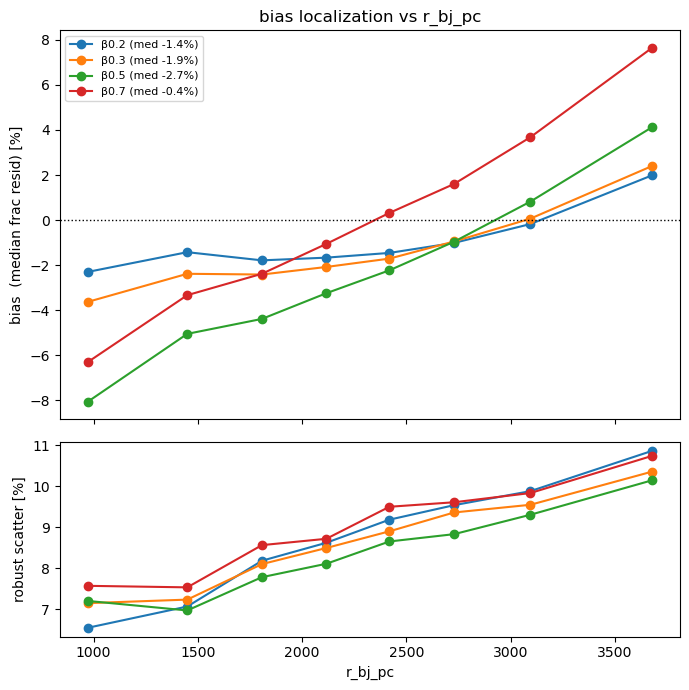

In [25]:
# Overlay the bias localization across the beta sweep (inline version of
# spphot_plots.bias_localization, built on E.bias_bins so it runs on the remote
# kernel without needing the latest spphot_plots.py pulled). Top panel: bias
# (median frac resid) -> should be flat at 0; a trend means regime-localized bias
# (de-bias there or raise beta). Bottom panel: in-bin robust scatter for context.
betas = [0.2, 0.3, 0.5, 0.7]

def plot_bias_localization(by_key=None, by_label="pred_err_frac", nbins=8,
                           snr_thresh=20.0):
    fig, (ax_b, ax_s) = plt.subplots(2, 1, figsize=(7, 7), sharex=True,
                                     gridspec_kw={"height_ratios": [2, 1]})
    for i, beta in enumerate(betas):
        df = data[beta]
        d = df[df["sample"].astype(str).str.strip().isin(["A", "B"])]  # held-out only
        by = d[by_key].values if by_key else None
        bins, axis_lab = E.bias_bins(d.plx_sp.values, d.plx.values,
                                     d.e_plx.values, d.err_sp.values,
                                     by=by, by_label=by_label,
                                     nbins=nbins, snr_thresh=snr_thresh)
        if not bins:
            continue
        x  = [b["axis_med"] for b in bins]
        bi = [100 * b["bias"] for b in bins]
        sc = [100 * b["scatter"] for b in bins]
        glob = 100 * np.median([b["bias"] for b in bins])
        ax_b.plot(x, bi, "o-", color=f"C{i}", label=f"β{beta} (med {glob:+.1f}%)")
        ax_s.plot(x, sc, "o-", color=f"C{i}")
    ax_b.axhline(0, color="k", lw=1, ls=":")
    ax_b.set(ylabel="bias  (median frac resid) [%]",
             title=f"bias localization vs {by_label}")
    ax_b.legend(fontsize=8)
    ax_s.set(xlabel=by_label, ylabel="robust scatter [%]")
    plt.tight_layout()
    plt.show()

plot_bias_localization()                                              # vs predicted err frac
plot_bias_localization(by_key="r_med_photogeo_pc", by_label="r_bj_pc")  # vs BJ distance


coverage (Gaia within k-sigma; honest Gaussian -> 68.3 / 95.4 / 99.7%)
  beta0.2:  1sig 53.8%   2sig 83.0%   3sig 94.1%   |z|>3 5.93%   w=1.35
  beta0.3:  1sig 56.9%   2sig 85.6%   3sig 95.4%   |z|>3 4.62%   w=1.25
  beta0.5:  1sig 67.4%   2sig 93.3%   3sig 98.5%   |z|>3 1.53%   w=0.99
  beta0.7:  1sig 68.3%   2sig 93.8%   3sig 98.7%   |z|>3 1.33%   w=0.94


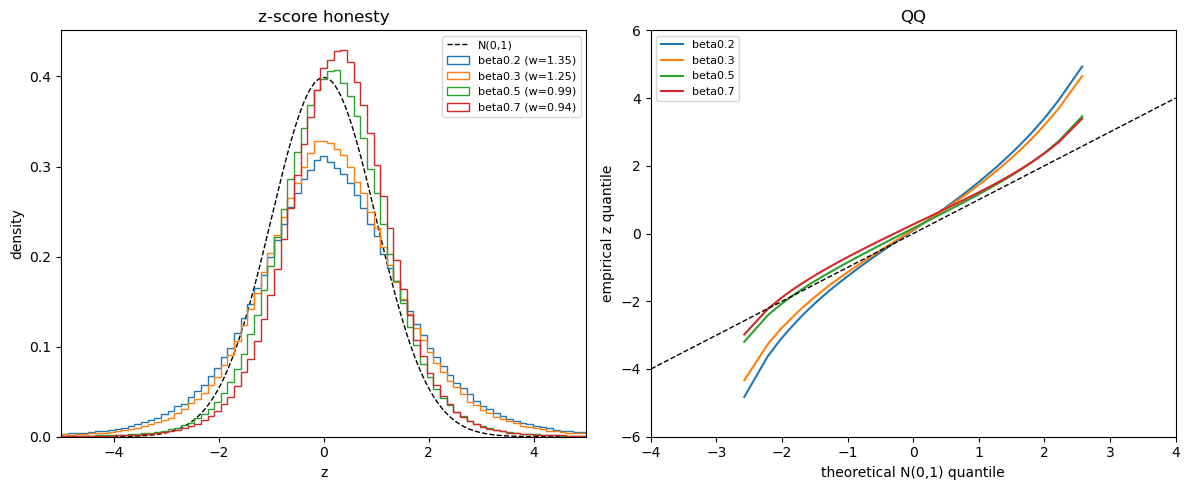

In [26]:
# (1) z-score honesty: z = (plx_sp - plx_a)/sqrt(err_sp^2 + err_a^2). Honest,
# Gaussian errors -> z ~ N(0,1). The hist shows core shift (bias) + core width
# (over/under-confidence); the QQ shows the OUTLIER TAIL (points splaying off the
# diagonal at the ends) that the robust metrics hide. Fat tail + unit-width core
# == the empirical case for the Student-t head. Inline copy of
# spphot_plots.zscore_diagnostic so it runs on the remote kernel.
import scipy.stats as ss

fig, (ax_h, ax_q) = plt.subplots(1, 2, figsize=(12, 5))
xx = np.linspace(-5, 5, 200)
ax_h.plot(xx, ss.norm.pdf(xx), "k--", lw=1, label="N(0,1)")
qq = np.linspace(0.005, 0.995, 120)
print("coverage (Gaia within k-sigma; honest Gaussian -> 68.3 / 95.4 / 99.7%)")
for i, beta in enumerate(betas):
    df = data[beta]
    d = df[df["sample"].astype(str).str.strip().isin(["A", "B"])]   # held-out
    z = (d.plx_sp.values - d.plx.values) / np.sqrt(d.err_sp.values**2 + d.e_plx.values**2)
    z = z[np.isfinite(z)]
    w = 1.48 * np.median(np.abs(z - np.median(z)))                  # robust width, ~1 if honest
    cov = [np.mean(np.abs(z) <= k) for k in (1, 2, 3)]
    print(f"  beta{beta}:  1sig {100*cov[0]:4.1f}%   2sig {100*cov[1]:4.1f}%   "
          f"3sig {100*cov[2]:4.1f}%   |z|>3 {100*np.mean(np.abs(z) > 3):.2f}%   w={w:.2f}")
    ax_h.hist(z, bins=np.linspace(-5, 5, 80), density=True, histtype="step",
              color=f"C{i}", label=f"beta{beta} (w={w:.2f})")
    ax_q.plot(ss.norm.ppf(qq), np.quantile(np.clip(z, -12, 12), qq), color=f"C{i}",
              label=f"beta{beta}")
ax_h.set(xlim=(-5, 5), xlabel="z", ylabel="density", title="z-score honesty")
ax_h.legend(fontsize=8)
ax_q.plot([-4, 4], [-4, 4], "k--", lw=1)
ax_q.set(xlim=(-4, 4), ylim=(-6, 6), xlabel="theoretical N(0,1) quantile",
         ylabel="empirical z quantile", title="QQ")
ax_q.legend(fontsize=8)
plt.tight_layout(); plt.show()


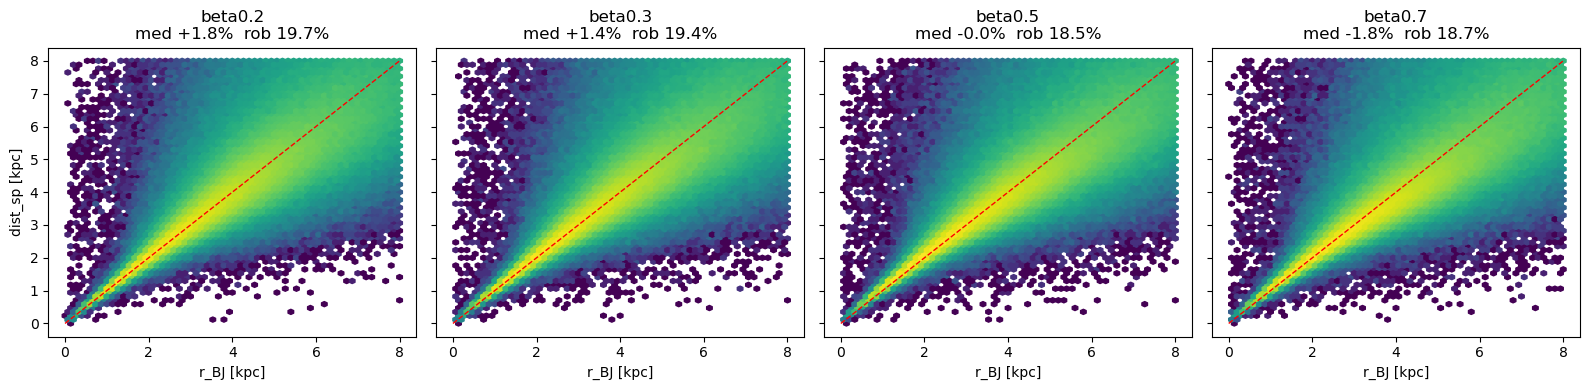

In [27]:
# (2) Spec distance vs Bailer-Jones photogeo distance. r_bj is prior-dominated
# where the Gaia parallax is noisy, so this probes the FAR stars Gaia-based eval
# can't referee (the hi-S/N probe is all nearby). Not fully independent (BJ also
# uses Gaia), but a different estimator -> a useful extrapolation cross-check.
# Panel title: median offset and robust frac scatter of (dist_sp - r_bj)/r_bj.
LIM = 8.0   # kpc
fig, axes = plt.subplots(1, len(betas), figsize=(4*len(betas), 4),
                         sharex=True, sharey=True)
for ax, beta in zip(np.atleast_1d(axes), betas):
    df = data[beta]
    d_sp = df.dist_sp_kpc.values
    r_bj = df.r_med_photogeo_pc.values / 1000.0          # pc -> kpc
    m = np.isfinite(d_sp) & np.isfinite(r_bj) & (d_sp > 0) & (r_bj > 0)
    d_sp, r_bj = d_sp[m], r_bj[m]
    ax.hexbin(r_bj, d_sp, gridsize=60, bins="log", extent=(0, LIM, 0, LIM),
              cmap="viridis")
    ax.plot([0, LIM], [0, LIM], "r--", lw=1)
    frac = (d_sp - r_bj) / r_bj
    rob = 1.48 * np.median(np.abs(frac - np.median(frac)))
    ax.set(xlabel="r_BJ [kpc]",
           title=f"beta{beta}\nmed {100*np.median(frac):+.1f}%  rob {100*rob:.1f}%")
np.atleast_1d(axes)[0].set_ylabel("dist_sp [kpc]")
plt.tight_layout(); plt.show()


error-head sharpness (Spearman rho: predicted err_sp vs realized |resid|)
  beta0.2:  rho = 0.230
  beta0.3:  rho = 0.269
  beta0.5:  rho = 0.386
  beta0.7:  rho = 0.347


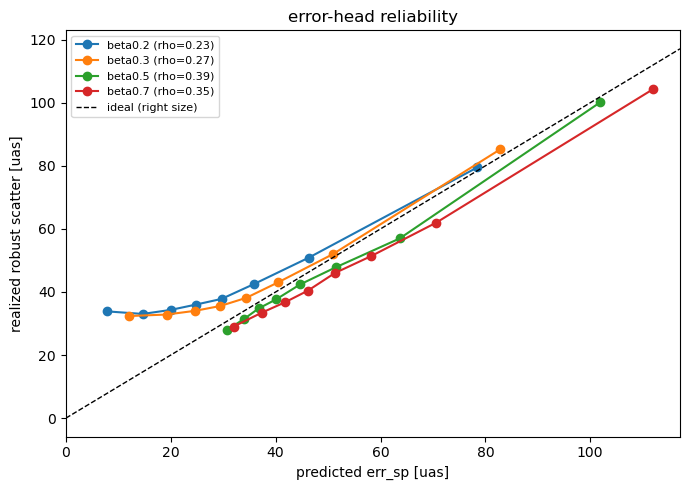

In [28]:
# (3) Does the per-star error head actually work? Spearman rho between predicted
# err_sp and realized |residual| on the hi-S/N probe. rho ~ 0 => the het head is
# decorative (a constant error would score as well); clearly positive => beta is
# buying real per-star uncertainty. The reliability curve bins by predicted err
# and plots the realized robust scatter; on the diagonal == per-star errors are
# the right SIZE, not just correctly ranked.
def spearman(x, y):
    rx = np.argsort(np.argsort(x)).astype(float)
    ry = np.argsort(np.argsort(y)).astype(float)
    rx -= rx.mean(); ry -= ry.mean()
    return float(rx @ ry / np.sqrt((rx @ rx) * (ry @ ry)))

print("error-head sharpness (Spearman rho: predicted err_sp vs realized |resid|)")
fig, ax = plt.subplots(figsize=(7, 5))
for i, beta in enumerate(betas):
    df = data[beta]
    d = df[df["sample"].astype(str).str.strip().isin(["A", "B"])]
    probe = (d.plx.values / d.e_plx.values) >= 20                  # hi-S/N: err_sp carries the scatter
    err = d.err_sp.values[probe]
    resid = (d.plx_sp.values - d.plx.values)[probe]
    mm = np.isfinite(err) & np.isfinite(resid) & (err > 0)
    err, resid = err[mm], resid[mm]
    rho = spearman(err, np.abs(resid))
    print(f"  beta{beta}:  rho = {rho:.3f}")
    edges = np.quantile(err, np.linspace(0, 1, 9))                 # reliability: realized vs predicted size
    xc, yc = [], []
    for j in range(8):
        b = (err >= edges[j]) & (err <= edges[j + 1] if j == 7 else err < edges[j + 1])
        if b.sum() < 50:
            continue
        xc.append(np.median(err[b]) * 1e3)                         # mas -> uas
        yc.append(1.48 * np.median(np.abs(resid[b] - np.median(resid[b]))) * 1e3)
    ax.plot(xc, yc, "o-", color=f"C{i}", label=f"beta{beta} (rho={rho:.2f})")
lo, hi = ax.get_xlim()
ax.plot([0, hi], [0, hi], "k--", lw=1, label="ideal (right size)")
ax.set(xlim=(0, hi), xlabel="predicted err_sp [uas]",
       ylabel="realized robust scatter [uas]", title="error-head reliability")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()


In [29]:
# (4) Error-head summary table across the sweep -- everything the updated
# train_nn.run_config now logs to wandb, computed post-hoc on the saved parquets
# (no retrain needed; the models are unchanged). Held-out rows only (sample A/B).
#   sharpness rho : Spearman(err_sp, |resid|) on hi-S/N probe; ~0 => head decorative
#   z width       : robust width of z=(plx_sp-plx_a)/sqrt(err_sp^2+err_a^2); 1=honest
#   |z|>3         : tail excess (Gaussian 0.27%); large => Student-t case
#   cov 1sig      : Gaia within 1sigma; honest Gaussian -> 68.3%
#   clamp lo/hi   : fraction of err_sp pinned at the [1e-4, 10] mas rails
#                   (gauss std_factor=1, so err_sp IS the clamped sigma)
CLAMP_LO, CLAMP_HI = 1e-4, 10.0    # exp(LOG_SIG_MIN), exp(LOG_SIG_MAX) from train_nn

def _spearman(x, y):
    rx = np.argsort(np.argsort(x)).astype(float)
    ry = np.argsort(np.argsort(y)).astype(float)
    rx -= rx.mean(); ry -= ry.mean()
    return float(rx @ ry / np.sqrt((rx @ rx) * (ry @ ry)))

print(f"{'beta':>5} {'rho':>6} {'z_w':>6} {'|z|>3%':>7} {'cov1s%':>7} "
      f"{'clmpLo%':>8} {'clmpHi%':>8}")
for beta in betas:
    df = data[beta]
    d = df[df["sample"].astype(str).str.strip().isin(["A", "B"])]
    plx_sp, plx_a = d.plx_sp.values, d.plx.values
    err_sp, err_a = d.err_sp.values, d.e_plx.values
    probe = (plx_a / err_a) >= 20
    rr = np.abs(plx_sp - plx_a)[probe]
    ee = err_sp[probe]
    mm = np.isfinite(ee) & np.isfinite(rr) & (ee > 0)
    rho = _spearman(ee[mm], rr[mm])
    z = (plx_sp - plx_a) / np.sqrt(err_sp**2 + err_a**2)
    z = z[np.isfinite(z)]
    zw = 1.48 * np.median(np.abs(z - np.median(z)))
    tail = 100 * np.mean(np.abs(z) > 3)
    cov1 = 100 * np.mean(np.abs(z) <= 1)
    sig = err_sp[np.isfinite(err_sp)]               # gauss: std_factor = 1
    lo = 100 * np.mean(sig <= CLAMP_LO * 1.01)
    hi = 100 * np.mean(sig >= CLAMP_HI * 0.99)
    print(f"{beta:>5} {rho:>+6.3f} {zw:>6.2f} {tail:>7.2f} {cov1:>7.1f} "
          f"{lo:>8.2f} {hi:>8.2f}")
print("\nrho~0 => decorative head | z_w>1 => overconfident | |z|>3 >> 0.27% => fat tail"
      " | cov1s < 68% => overconfident | clamp% non-trivial => clamp doing model work")


 beta    rho    z_w  |z|>3%  cov1s%  clmpLo%  clmpHi%
  0.2 +0.230   1.35    5.93    53.8     0.12     0.00
  0.3 +0.269   1.25    4.62    56.9     0.01     0.00
  0.5 +0.386   0.99    1.53    67.4     0.00     0.00
  0.7 +0.347   0.94    1.33    68.3     0.00     0.00

rho~0 => decorative head | z_w>1 => overconfident | |z|>3 >> 0.27% => fat tail | cov1s < 68% => overconfident | clamp% non-trivial => clamp doing model work


In [30]:
original_data.columns

/jobfs/172291164.gadi-pbs/ipykernel_2333342/178113022.py:1: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  original_data.columns


['spectrum_pk',
 'release',
 'sdss_id',
 'telescope',
 'snr',
 'spectrum_flags',
 'continuum',
 'v_rad',
 'e_v_rad',
 'std_v_rad',
 'median_e_v_rad',
 'xcorr_v_rad',
 'wavelength',
 'flux',
 'ivar',
 'pixel_flags',
 'gaia_dr3_source_id',
 'phot_g_mean_mag',
 'nu_eff_used_in_astrometry',
 'pseudocolour',
 'ecl_lat',
 'astrometric_params_solved',
 'zeropoint']

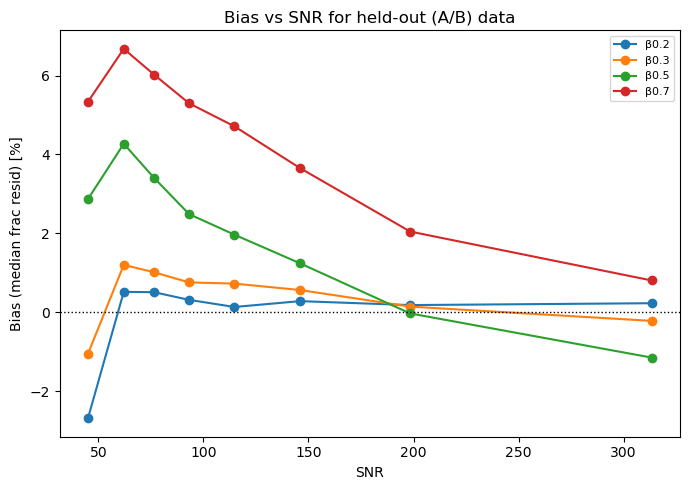

In [31]:
# Function to plot bias (median frac resid) vs a chosen column (e.g. SNR) for held-out (A/B) sample across betas

import matplotlib.pyplot as plt

def plot_bias_vs_column(column="snr", column_label=None, nbins=8, figsize=(7, 5)):
    """
    Plot bias (median frac resid) vs specified column for held-out (A/B) sample across betas.
    
    Parameters
    ----------
    column : str
        The column name in the data to use for binning on the x-axis (e.g., "snr", "r_med_photogeo_pc", etc).
    column_label : str or None
        The label for the x-axis. If None, uses the column name.
    nbins : int
        Number of bins to divide the column values into.
    figsize : tuple
        Figure size for the plot.
    """
    betas = [0.2, 0.3, 0.5, 0.7]
    if column_label is None:
        column_label = column

    # Get (sdss_id, <column>) mapping from original_data (robust to LazyFrame/eager API)
    if column == "snr":
        cols_to_get = ["sdss_id", column]
    else:
        # Always get snr for example, can be expanded
        cols_to_get = ["sdss_id", column]
    original_data_pd = original_data.select(cols_to_get).collect().to_pandas().dropna()
    value_map = dict(zip(original_data_pd["sdss_id"], original_data_pd[column]))

    plt.figure(figsize=figsize)
    plotted_any = False

    for i, beta in enumerate(betas):
        df = data[beta]
        held = df[df["sample"].astype(str).str.strip().isin(["A", "B"])]
        d = held.copy()

        # Attach column from master table if missing
        if column not in d.columns:
            d[column] = d["sdss_id"].map(value_map)

        # Only consider rows where both column and parallax values are present and finite
        mask = d[[column, "plx", "plx_sp"]].apply(lambda x: np.isfinite(x).all(), axis=1)
        d_valid = d[mask].copy()
        if d_valid.empty:
            continue

        col_vals = d_valid[column]
        # If not enough unique values to form bins, skip plotting for this beta
        if col_vals.nunique() < nbins:
            continue

        # Bin edges using quantiles, but ensure unique edges (required for np.digitize)
        bin_edges = np.unique(np.quantile(col_vals, np.linspace(0, 1, nbins + 1)))
        if len(bin_edges) <= 1:
            continue

        # Assign bin index to each sample, bins go from 1..nbins
        bin_idx = np.digitize(d_valid[column], bin_edges, right=False)

        bin_centers = []
        bias_bin = []
        # Only loop through bins that will contain samples (as np.digitize may exceed)
        for k in range(1, len(bin_edges)):
            inbin = bin_idx == k
            if not np.any(inbin):
                continue
            subset = d_valid.loc[inbin]
            submask = np.isfinite(subset["plx"]) & np.isfinite(subset["plx_sp"]) & (subset["plx"] != 0)
            subset = subset[submask]
            if subset.empty:
                continue
            ratio = (subset["plx_sp"] - subset["plx"]) / subset["plx"]
            ratio = ratio[np.isfinite(ratio)]
            if ratio.empty:
                continue
            bias = np.median(ratio)
            median_col = np.median(subset[column])
            bias_bin.append(bias * 100)
            bin_centers.append(median_col)

        if len(bin_centers) > 0:
            plt.plot(bin_centers, bias_bin, "o-", label=f"β{beta}")
            plotted_any = True

    plt.axhline(0, color="k", lw=1, ls=":")
    plt.xlabel(column_label)
    plt.ylabel("Bias (median frac resid) [%]")
    plt.title(f"Bias vs {column_label} for held-out (A/B) data")
    if plotted_any:
        plt.legend(fontsize=8)
    else:
        plt.text(0.5, 0.5, "No data to plot", horizontalalignment="center", verticalalignment="center", transform=plt.gca().transAxes)
    plt.tight_layout()
    plt.show()

# Example usage: plot bias vs SNR (as before)
plot_bias_vs_column(column="snr", column_label="SNR", nbins=8)

# Example usage: plot bias vs BJ distance (replace with valid column name if needed)
# plot_bias_vs_column(column="r_med_photogeo_pc", column_label="r_bj_pc", nbins=8)

In [32]:
original_data.columns

/jobfs/172291164.gadi-pbs/ipykernel_2333342/178113022.py:1: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  original_data.columns


['spectrum_pk',
 'release',
 'sdss_id',
 'telescope',
 'snr',
 'spectrum_flags',
 'continuum',
 'v_rad',
 'e_v_rad',
 'std_v_rad',
 'median_e_v_rad',
 'xcorr_v_rad',
 'wavelength',
 'flux',
 'ivar',
 'pixel_flags',
 'gaia_dr3_source_id',
 'phot_g_mean_mag',
 'nu_eff_used_in_astrometry',
 'pseudocolour',
 'ecl_lat',
 'astrometric_params_solved',
 'zeropoint']

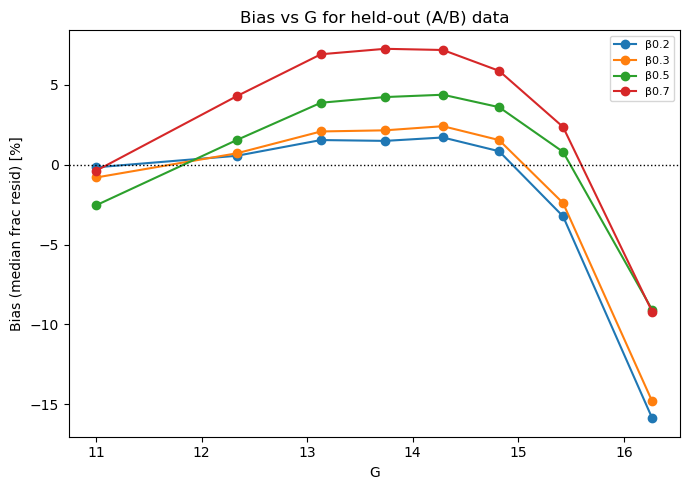

In [33]:
plot_bias_vs_column(column="phot_g_mean_mag", column_label=f"G", nbins=8)

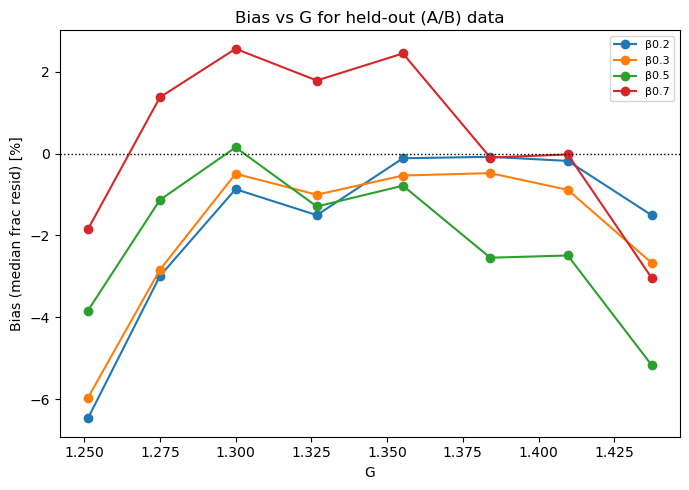

In [34]:
plot_bias_vs_column(column="pseudocolour", column_label=f"G", nbins=8)

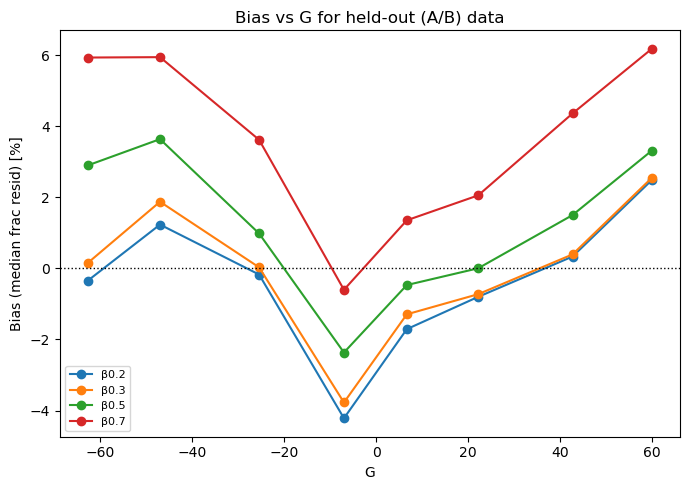

In [35]:
plot_bias_vs_column(column="ecl_lat", column_label=f"G", nbins=8)

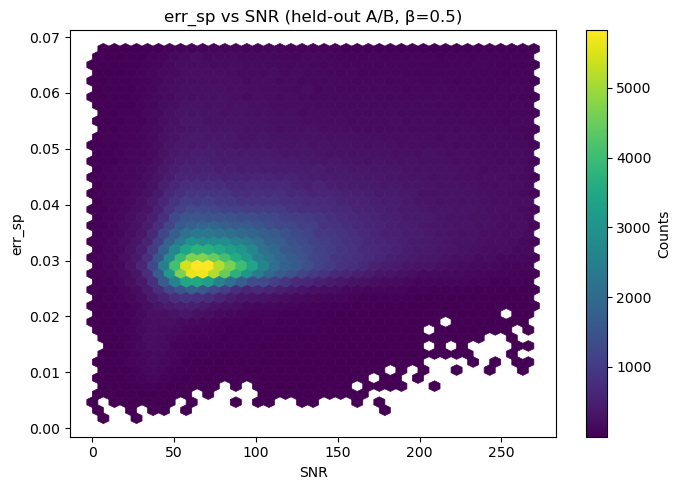

In [36]:
# Function to plot hexbin of err_sp vs a chosen column for held-out (A/B) sample across betas

import matplotlib.pyplot as plt

def plot_hexbin_err_sp_vs_column(column="snr", column_label=None, beta=0.5, gridsize=40, figsize=(7, 5), cmap="viridis"):
    """
    Plot hexbin of err_sp vs specified column for held-out (A/B) sample for a chosen beta.

    Parameters
    ----------
    column : str
        The column name in the data to use for the x-axis (e.g., "snr", "r_med_photogeo_pc", etc).
    column_label : str or None
        The label for the x-axis. If None, uses the column name.
    beta : float
        Beta value to select from the data dictionary.
    gridsize : int
        The number of hexagons in the x-direction.
    figsize : tuple
        Figure size for the plot.
    cmap : str
        Colormap for the hexbin plot.
    """
    if column_label is None:
        column_label = column

    # Get (sdss_id, <column>) mapping from original_data (robust to LazyFrame/eager API)
    cols_to_get = ["sdss_id", column]
    original_data_pd = original_data.select(cols_to_get).collect().to_pandas().dropna()
    value_map = dict(zip(original_data_pd["sdss_id"], original_data_pd[column]))

    df = data[beta]
    held = df[df["sample"].astype(str).str.strip().isin(["A", "B"])]
    d = held.copy()

    # Attach column from master table if missing
    if column not in d.columns:
        d[column] = d["sdss_id"].map(value_map)

    # Only consider rows where both err_sp and requested column are present and finite
    mask = d[[column, "err_sp"]].apply(lambda x: np.isfinite(x).all(), axis=1)
    d_valid = d[mask].copy()
    if d_valid.empty:
        print("No valid data to plot.")
        return

    x = d_valid[column]
    y = d_valid["err_sp"]
    
    # Sigma clip x and y using a simple method (e.g., |x - median| < n * std)
    from astropy.stats import sigma_clip

    xy = np.column_stack((x, y))
    # Perform 3-sigma clipping on both dimensions; mask rows where either is clipped
    clipped = sigma_clip(xy, sigma=3, axis=0)
    mask = (~clipped.mask).all(axis=1)
    x = x[mask]
    y = y[mask]

    plt.figure(figsize=figsize)
    hb = plt.hexbin(x, y, gridsize=gridsize, cmap=cmap, mincnt=1, linewidths=0.5)
    cb = plt.colorbar(hb)
    cb.set_label("Counts")

    plt.xlabel(column_label)
    plt.ylabel("err_sp")
    plt.title(f"err_sp vs {column_label} (held-out A/B, β={beta})")
    plt.tight_layout()
    plt.show()

# Example usage: plot hexbin of err_sp vs SNR for beta=0.5
plot_hexbin_err_sp_vs_column(column="snr", column_label="SNR", beta=0.5, gridsize=40)

# Example: plot hexbin of err_sp vs BJ distance (change column as needed)
# plot_hexbin_err_sp_vs_column(column="r_med_photogeo_pc", column_label="r_bj_pc", beta=0.5)

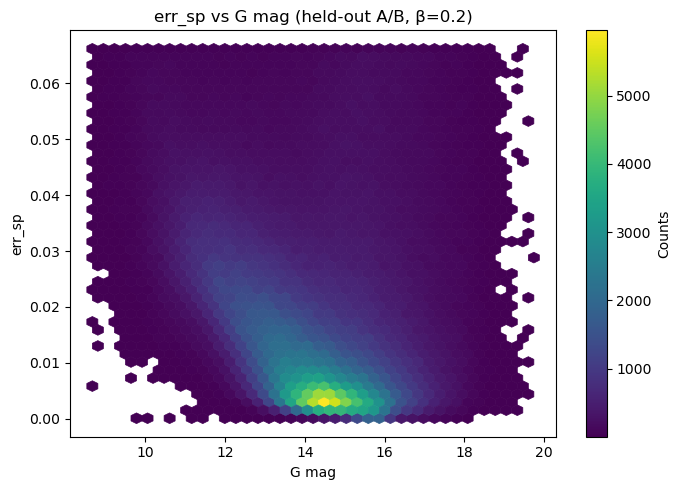

In [37]:
plot_hexbin_err_sp_vs_column(column="phot_g_mean_mag", column_label="G mag", beta=0.2, gridsize=40)

(array([5.00000e+00, 1.64000e+02, 8.65000e+02, 6.64500e+03, 5.48650e+04,
        1.75184e+05, 3.06971e+05, 2.17880e+05, 6.22330e+04, 4.36000e+02]),
 array([ 2.01642513,  3.87854862,  5.74067211,  7.6027956 ,  9.46491909,
        11.32704258, 13.18916607, 15.05128956, 16.913414  , 18.77553558,
        20.63765907]),
 <BarContainer object of 10 artists>)

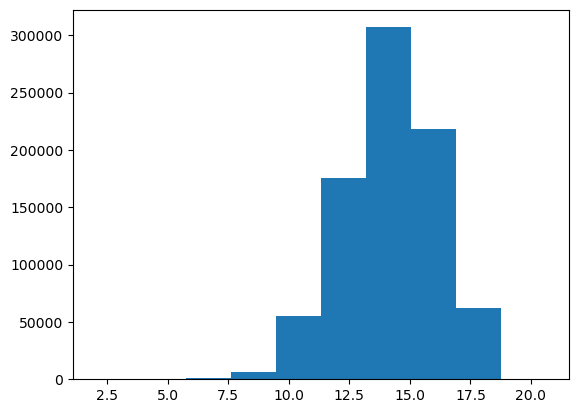

In [38]:
plt.hist(original_data.select(["phot_g_mean_mag"]).collect())

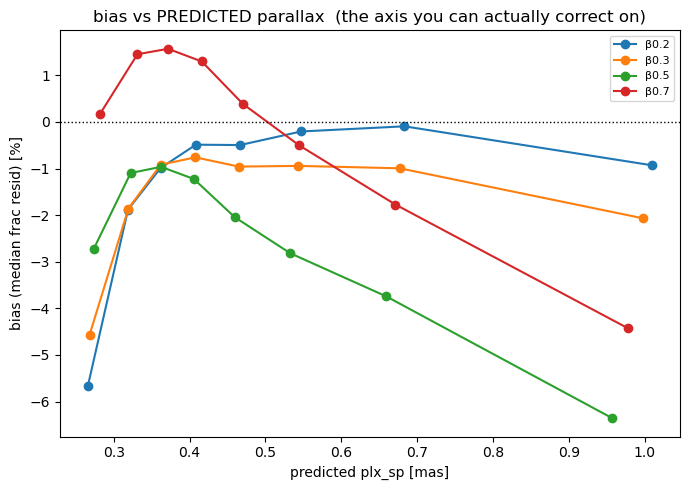

In [39]:
# (5a) The CORRECTABLE bias axis: residual binned by PREDICTED parallax plx_sp
# (an observable you have at inference), NOT by true/BJ distance. The slope here
# is OPPOSITE to the r_bj curve -- that is the regression direction, and the
# reason you fit E[resid | plx_sp] on the prediction and never invert the
# truth-indexed plot. Held-out rows (A/B), hi-S/N probe.
def _frac(d):
    return (d.plx_sp.values - d.plx.values) / d.plx.values

def _binmed(x, y, nb=8, minn=50):
    e = np.quantile(x, np.linspace(0, 1, nb + 1))
    xs, ys = [], []
    for j in range(nb):
        m = (x >= e[j]) & (x <= e[j + 1] if j == nb - 1 else x < e[j + 1])
        if m.sum() < minn:
            continue
        xs.append(np.median(x[m])); ys.append(np.median(y[m]))
    return np.array(xs), np.array(ys)

fig, ax = plt.subplots(figsize=(7, 5))
for i, beta in enumerate(betas):
    d = data[beta]
    d = d[d["sample"].astype(str).str.strip().isin(["A", "B"])]
    dp = d[(d.plx.values / d.e_plx.values) >= 20]
    xs, ys = _binmed(dp.plx_sp.values, _frac(dp))
    ax.plot(xs, 100 * ys, "o-", color=f"C{i}", label=f"β{beta}")
ax.axhline(0, color="k", lw=1, ls=":")
ax.set(xlabel="predicted plx_sp [mas]", ylabel="bias (median frac resid) [%]",
       title="bias vs PREDICTED parallax  (the axis you can actually correct on)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()


held-out fold B, β0.2:
  global bias     -1.16%  ->  -0.03%
  robust scatter  8.63%  ->  8.63%   (should be ~unchanged)


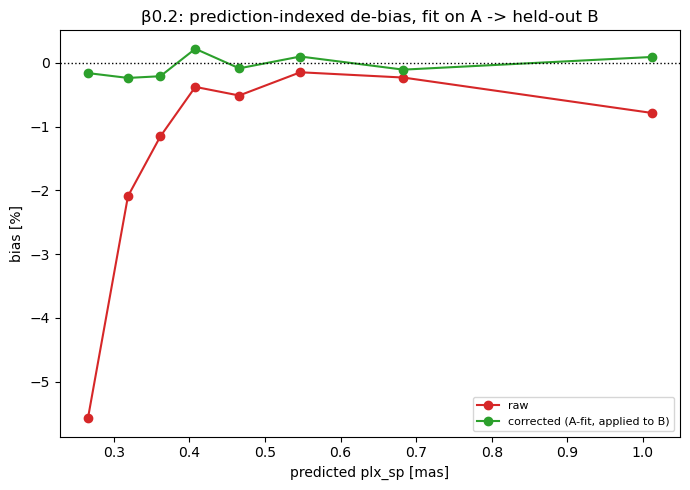

In [40]:
# (5b) No-circularity de-bias DEMO: fit the correction on fold A, apply to held-out
# fold B. The index is plx_sp (observable at inference); Gaia truth is used ONLY to
# fit on A. Correction: plx_true ~ plx_sp / (1 + b(plx_sp)), b = E[frac resid|plx_sp].
# Success = global bias -> ~0 on B while robust scatter is UNCHANGED (a de-bias
# moves the center, it cannot tighten the scatter -- that needs beta/Student-t).
beta = 0.2
df = data[beta]
A = df[df["sample"].astype(str).str.strip() == "A"]
B = df[df["sample"].astype(str).str.strip() == "B"]
pa = (A.plx.values / A.e_plx.values) >= 20
gx, gy = _binmed(A.plx_sp.values[pa], _frac(A)[pa], nb=12)     # fit bias(plx_sp) on A only

def debias(plx_sp):
    return plx_sp / (1.0 + np.interp(plx_sp, gx, gy))          # flat extrapolation at the ends

Bp = B[(B.plx.values / B.e_plx.values) >= 20]
raw = (Bp.plx_sp.values - Bp.plx.values) / Bp.plx.values
cor = (debias(Bp.plx_sp.values) - Bp.plx.values) / Bp.plx.values
rob = lambda v: 1.48 * np.median(np.abs(v - np.median(v)))
print(f"held-out fold B, β{beta}:")
print(f"  global bias     {100*np.median(raw):+.2f}%  ->  {100*np.median(cor):+.2f}%")
print(f"  robust scatter  {100*rob(raw):.2f}%  ->  {100*rob(cor):.2f}%   (should be ~unchanged)")

fig, ax = plt.subplots(figsize=(7, 5))
for v, lab, c in [(raw, "raw", "C3"), (cor, "corrected (A-fit, applied to B)", "C2")]:
    xs, ys = _binmed(Bp.plx_sp.values, v)
    ax.plot(xs, 100 * ys, "o-", color=c, label=lab)
ax.axhline(0, color="k", lw=1, ls=":")
ax.set(xlabel="predicted plx_sp [mas]", ylabel="bias [%]",
       title=f"β{beta}: prediction-indexed de-bias, fit on A -> held-out B")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()


In [41]:
import spphot_eval as E

for beta in [0.2, 0.5]:                      # compare the broken one vs the candidate
    df = data[beta]
    d = df[df["sample"].astype(str).str.strip().isin(["A", "B"])]   # held-out only
    bins = E.calibration_bins(d.plx_sp.values, d.plx.values,
                              d.e_plx.values, d.err_sp.values,
                              snr_thresh=20.0)                       # hi-S/N probe
    c = E.recalibration_factor(d.plx_sp.values, d.plx.values,
                               d.e_plx.values, d.err_sp.values)
    print(f"\n=== beta {beta} ===")
    E.print_calibration(bins, c)


=== beta 0.2 ===
  error calibration (high-S/N probe, binned by predicted err frac):
    pred%   obs%   obs/pred  robustChi    N
     2.40   9.86     4.11      2.25    18935
     3.97   8.49     2.14      1.69    18934
     5.01   7.60     1.52      1.35    18934
     5.75   7.36     1.28      1.19    18934
     6.40   7.35     1.15      1.08    18934
     7.07   7.83     1.11      1.03    18934
     7.92   8.81     1.11      1.01    18934
     9.90  13.20     1.33      1.05    18935
    (obs/pred & robustChi > 1 -> overconfident; flat across rows = scalar recal ok, trend = needs mag-dependent recal)
  global recal factor (err_sp *= c -> robust chi ~ 1): c = 1.864

=== beta 0.5 ===
  error calibration (high-S/N probe, binned by predicted err frac):
    pred%   obs%   obs/pred  robustChi    N
     8.46   7.18     0.85      0.83    18935
     8.97   8.22     0.92      0.86    18934
     9.35   9.03     0.97      0.90    18934
     9.73   9.82     1.01      0.92    18934
    10.15   9.84

In [42]:
# Distance- and magnitude-resolved calibration on the hi-S/N probe.
# Same obs/pred construction as E.calibration_bins, but binned by an EXTERNAL
# axis (BJ distance / G mag) instead of predicted err frac. This localizes the
# top-bin overconfidence: if obs/pred climbs past 1 at large r_BJ / faint G, the
# miscalibration is a DISTANCE effect (-> your bulge regime, must caveat); if it
# stays flat vs distance, the earlier top-bin effect was spectral difficulty, not
# distance. Held-out (A/B) only; err_a deconvolved -> probe-restricted is required.

def robust(v):
    v = v[np.isfinite(v)]
    return 1.48 * np.median(np.abs(v - np.median(v)))

def calib_by_axis(d, axis_vals, axis_label, nbins=8, snr_thresh=20.0):
    plx_sp, plx_a = d.plx_sp.values, d.plx.values
    err_a, err_sp = d.e_plx.values, d.err_sp.values
    axis = np.asarray(axis_vals, float)
    probe = (plx_a / err_a) >= snr_thresh
    m = probe & np.isfinite(axis) & (plx_sp > 0) & (err_sp > 0) & np.isfinite(err_a)
    plx_sp, plx_a, err_a, err_sp, axis = (plx_sp[m], plx_a[m], err_a[m],
                                          err_sp[m], axis[m])
    edges = np.quantile(axis, np.linspace(0, 1, nbins + 1))
    edges[-1] = np.inf
    print(f"  {axis_label:>10}   pred%   obs%  obs/pred  robChi      N")
    for i in range(nbins):
        b = (axis >= edges[i]) & (axis < edges[i + 1])
        if b.sum() < 50:
            continue
        resid = plx_sp[b] - plx_a[b]
        obs_var = robust(resid)**2 - np.median(err_a[b]**2)
        obs_sig = np.sqrt(max(obs_var, 0.0))
        med_plx = np.median(plx_sp[b])
        pred_f = np.median((err_sp[b] / plx_sp[b]))
        obs_f  = obs_sig / med_plx if med_plx > 0 else np.nan
        chi = resid / np.sqrt(err_a[b]**2 + err_sp[b]**2)
        robchi = robust(chi)
        print(f"  {np.median(axis[b]):>10.3g}  {100*pred_f:5.2f}  {100*obs_f:5.2f}"
              f"   {obs_f/pred_f:6.2f}   {robchi:5.2f}  {b.sum():6d}")
    print("  (obs/pred & robChi > 1 -> overconfident in that bin)")

# pull G mag from the master table (cell-11 pattern), distance is already in the parquet
gmap = (original_data.select(["sdss_id", "phot_g_mean_mag"])
        .collect().to_pandas().dropna())
gmap = dict(zip(gmap["sdss_id"], gmap["phot_g_mean_mag"]))

for beta in [0.5]:                            # the candidate; add 0.2 to contrast
    df = data[beta]
    d = df[df["sample"].astype(str).str.strip().isin(["A", "B"])].copy()
    d["G"] = d["sdss_id"].map(gmap)
    print(f"\n=== beta {beta}: calibration vs BJ distance ===")
    calib_by_axis(d, d.r_med_photogeo_pc.values / 1000.0, "r_BJ_kpc")
    print(f"\n=== beta {beta}: calibration vs G mag ===")
    calib_by_axis(d, d["G"].values, "G_mag")


=== beta 0.5: calibration vs BJ distance ===
    r_BJ_kpc   pred%   obs%  obs/pred  robChi      N
       0.973   9.99   8.77     0.88    0.80   18932
        1.45   9.12   6.98     0.77    0.80   18932
        1.81   9.20   7.57     0.82    0.85   18932
        2.12   9.42   7.68     0.82    0.83   18931
        2.42   9.72   8.05     0.83    0.84   18932
        2.73  10.09   8.04     0.80    0.82   18932
        3.09  10.53   8.27     0.79    0.80   18932
        3.68  11.24   8.63     0.77    0.78   18932
  (obs/pred & robChi > 1 -> overconfident in that bin)

=== beta 0.5: calibration vs G mag ===
       G_mag   pred%   obs%  obs/pred  robChi      N
        9.71  10.20   9.41     0.92    0.83   18935
        10.7   9.31   7.56     0.81    0.78   18934
        11.3   9.29   7.96     0.86    0.84   18934
        11.8   9.55   8.60     0.90    0.88   18934
        12.2   9.96   9.31     0.93    0.91   18934
        12.7  10.18  10.71     1.05    1.02   18934
        13.2  10.55   8.9

In [43]:
# Probe-restricted recalibration, no circularity: fit the scalar c on held-out
# fold A's hi-S/N probe, apply err_sp *= c to held-out fold B, then re-make the
# distance-binned calibration table on B. Expectation from the ~0.80 obs/pred we
# saw: c ~ 0.83 (SHRINK err_sp ~17%), and post-shrink obs/pred should sit ~1.0
# flat across distance. A/B separation keeps c honest (fit and apply never share
# stars). This is the real recal -- the full-sample c=0.99 was Gaia-dominated and
# hid the spec-error over-caution.
beta = 0.5
df = data[beta]
A = df[df["sample"].astype(str).str.strip() == "A"]
B = df[df["sample"].astype(str).str.strip() == "B"]

# --- fit c on fold A, PROBE ONLY ---
pa = (A.plx.values / A.e_plx.values) >= 20
cA = E.recalibration_factor(A.plx_sp.values[pa], A.plx.values[pa],
                            A.e_plx.values[pa], A.err_sp.values[pa])
print(f"recal factor fit on fold-A probe: c = {cA:.3f}  "
      f"({'shrink' if cA < 1 else 'inflate'} err_sp by {abs(1-cA)*100:.0f}%)")

# --- apply to held-out fold B, re-make the distance table ---
B = B.copy()
B["err_sp_recal"] = B.err_sp.values * cA

def calib_by_axis_cols(plx_sp, plx_a, err_a, err_sp, axis_vals, axis_label,
                       nbins=8, snr_thresh=20.0):
    axis = np.asarray(axis_vals, float)
    probe = (plx_a / err_a) >= snr_thresh
    m = probe & np.isfinite(axis) & (plx_sp > 0) & (err_sp > 0) & np.isfinite(err_a)
    plx_sp, plx_a, err_a, err_sp, axis = (plx_sp[m], plx_a[m], err_a[m],
                                          err_sp[m], axis[m])
    edges = np.quantile(axis, np.linspace(0, 1, nbins + 1)); edges[-1] = np.inf
    rob = lambda v: 1.48 * np.median(np.abs(v[np.isfinite(v)] -
                                            np.median(v[np.isfinite(v)])))
    print(f"  {axis_label:>10}   pred%   obs%  obs/pred  robChi      N")
    for i in range(nbins):
        b = (axis >= edges[i]) & (axis < edges[i + 1])
        if b.sum() < 50:
            continue
        resid = plx_sp[b] - plx_a[b]
        obs_sig = np.sqrt(max(rob(resid)**2 - np.median(err_a[b]**2), 0.0))
        med = np.median(plx_sp[b])
        pf = np.median(err_sp[b] / plx_sp[b]); of = obs_sig / med
        chi = resid / np.sqrt(err_a[b]**2 + err_sp[b]**2)
        print(f"  {np.median(axis[b]):>10.3g}  {100*pf:5.2f}  {100*of:5.2f}"
              f"   {of/pf:6.2f}   {rob(chi):5.2f}  {b.sum():6d}")

rkpc = B.r_med_photogeo_pc.values / 1000.0
print(f"\n=== fold B, BEFORE recal (c=1.0) ===")
calib_by_axis_cols(B.plx_sp.values, B.plx.values, B.e_plx.values,
                   B.err_sp.values, rkpc, "r_BJ_kpc")
print(f"\n=== fold B, AFTER recal (err_sp *= {cA:.3f}) ===")
calib_by_axis_cols(B.plx_sp.values, B.plx.values, B.e_plx.values,
                   B.err_sp_recal.values, rkpc, "r_BJ_kpc")

# --- global z-width check on the probe, before vs after ---
def zwidth(es):
    z = (B.plx_sp.values - B.plx.values) / np.sqrt(es**2 + B.e_plx.values**2)
    z = z[(B.plx.values / B.e_plx.values >= 20) & np.isfinite(z)]
    return 1.48 * np.median(np.abs(z - np.median(z)))
print(f"\nprobe z-width on fold B:  before {zwidth(B.err_sp.values):.2f}"
      f"  ->  after {zwidth(B.err_sp_recal.values):.2f}  (target 1.00)")

recal factor fit on fold-A probe: c = 0.866  (shrink err_sp by 13%)

=== fold B, BEFORE recal (c=1.0) ===
    r_BJ_kpc   pred%   obs%  obs/pred  robChi      N
       0.975   9.96   8.68     0.87    0.78    9433
        1.45   9.10   6.99     0.77    0.80    9432
        1.81   9.19   7.55     0.82    0.85    9432
        2.12   9.44   7.88     0.83    0.86    9432
        2.42   9.77   8.15     0.83    0.85    9432
        2.73  10.16   7.96     0.78    0.81    9432
        3.09  10.59   8.21     0.78    0.80    9432
        3.68  11.30   8.64     0.76    0.78    9433

=== fold B, AFTER recal (err_sp *= 0.866) ===
    r_BJ_kpc   pred%   obs%  obs/pred  robChi      N
       0.975   8.63   8.68     1.01    0.89    9433
        1.45   7.89   6.99     0.89    0.91    9432
        1.81   7.96   7.55     0.95    0.96    9432
        2.12   8.18   7.88     0.96    0.97    9432
        2.42   8.46   8.15     0.96    0.96    9432
        2.73   8.80   7.96     0.90    0.91    9432
        3.09 